Variance Inflation Factors:
             feature       VIF
0             Radio  6.695980
1      Social Media  5.344600
2            TV_Low  1.661129
3         TV_Medium  1.664554
4   Influencer_Mega  1.996014
5  Influencer_Micro  2.083851
6   Influencer_Nano  2.084801
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.904
Model:                            OLS   Adj. R-squared:                  0.903
Method:                 Least Squares   F-statistic:                     760.4
Date:                Tue, 30 Jun 2026   Prob (F-statistic):          1.82e-282
Time:                        13:58:09   Log-Likelihood:                -2713.4
No. Observations:                 572   AIC:                             5443.
Df Residuals:                     564   BIC:                             5478.
Df Model:                           7                                         
Covariance Type:    

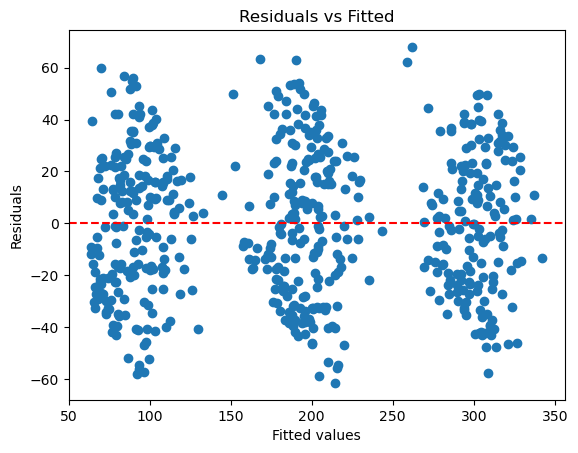

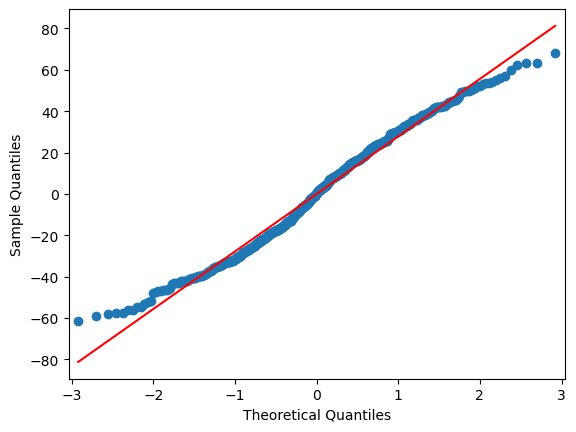

In [2]:
# Multiple Linear Regression Project Template working
# -------------------------------------------

# Step 1: Import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# Step 2: Load dataset
df = pd.read_csv(r"C:\Users\ACER\Downloads\c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv")

# Step 3: Encode categorical variables (TV, Influencer)
df_encoded = pd.get_dummies(df, columns=['TV','Influencer'], drop_first=True)

# Step 4: Define predictors (X) and target (y)
X = df_encoded.drop('Sales', axis=1)
y = df_encoded['Sales']

# ✅ Ensure all predictors are numeric floats
X = X.apply(pd.to_numeric, errors='coerce').astype(float)
y = pd.to_numeric(y, errors='coerce').astype(float)

# Step 5: Check multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("Variance Inflation Factors:\n", vif_data)

# Step 6: Fit regression model
X_const = sm.add_constant(X)  # add intercept
model = sm.OLS(y, X_const).fit()
print(model.summary())

# Step 7: Diagnostics
# Residuals vs Fitted
plt.scatter(model.fittedvalues, model.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

# QQ Plot for normality
sm.qqplot(model.resid, line='s')
plt.show()
